In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, confusion_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load Dataset
df = pd.read_csv("C:/Users/acer/Downloads/creditcard.csv")


In [5]:
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [6]:
print(df['Class'].value_counts())  # check imbalance

Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
# Feature Scaling (Amount column)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [8]:
# Split Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Handle Class Imbalance
# Using SMOTE for oversampling minority class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Optional: undersampling majority class
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print("Original class distribution:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())
print("After Undersampling:\n", y_train_bal.value_counts())

Original class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64
After Undersampling:
 Class
0    394
1    394
Name: count, dtype: int64


In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Evaluation
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
roc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC Score (LR):", roc_lr)

Logistic Regression Confusion Matrix:
 [[56244   620]
 [    9    89]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.91      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score (LR): 0.9755927677064072


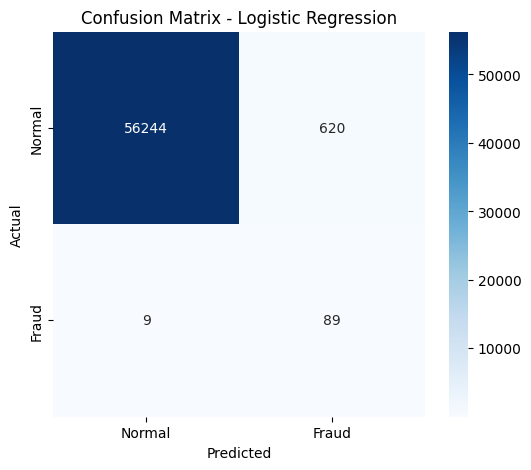

In [27]:

# Confusion matrix graph for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Normal","Fraud"],
            yticklabels=["Normal","Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [12]:
iso = IsolationForest(contamination=0.001, random_state=42)
iso.fit(X_train)

y_pred_iso = iso.predict(X_test)
# Convert -1 (anomaly) to 1 (fraud), 1 (normal) to 0
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# For ROC-AUC, Isolation Forest has decision_function
y_prob_iso = -iso.decision_function(X_test)  # higher = more anomalous

print("Isolation Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))
roc_iso = roc_auc_score(y_test, y_prob_iso)
print("ROC-AUC Score (Isolation Forest):", roc_iso)

Isolation Forest Confusion Matrix:
 [[56825    39]
 [   73    25]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.26      0.31        98

    accuracy                           1.00     56962
   macro avg       0.69      0.63      0.65     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score (Isolation Forest): 0.9543364475784686


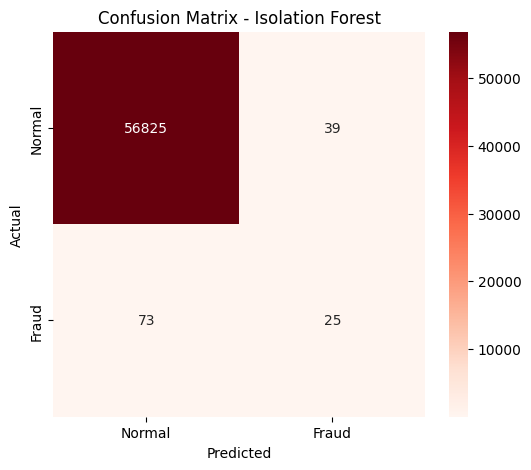

In [28]:

# Confusion matrix graph for Isolation
cm_iso = confusion_matrix(y_test, y_pred_iso)

plt.figure(figsize=(6,5))

sns.heatmap(cm_iso,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=["Normal","Fraud"],
            yticklabels=["Normal","Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Isolation Forest")

plt.show()

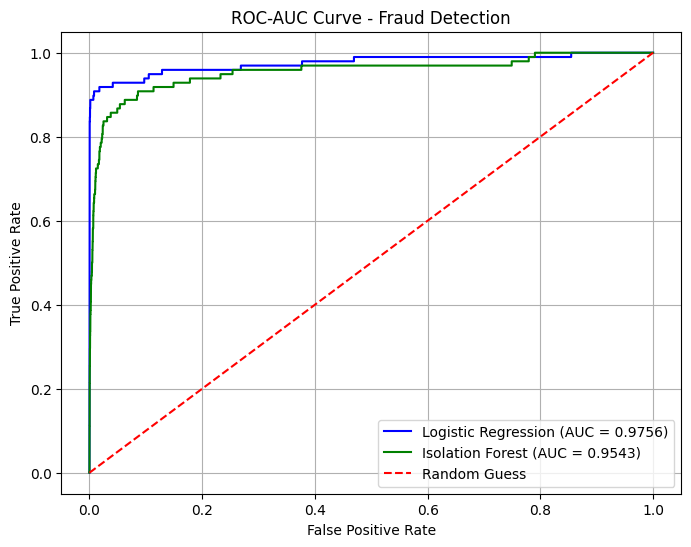

In [13]:
# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test, y_prob_iso)
roc_auc_iso = auc(fpr_iso, tpr_iso)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, color='blue', label='Logistic Regression (AUC = %0.4f)' % roc_auc_lr)
plt.plot(fpr_iso, tpr_iso, color='green', label='Isolation Forest (AUC = %0.4f)' % roc_auc_iso)
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Fraud Detection')
plt.legend(loc='lower right')
plt.grid()
plt.show()

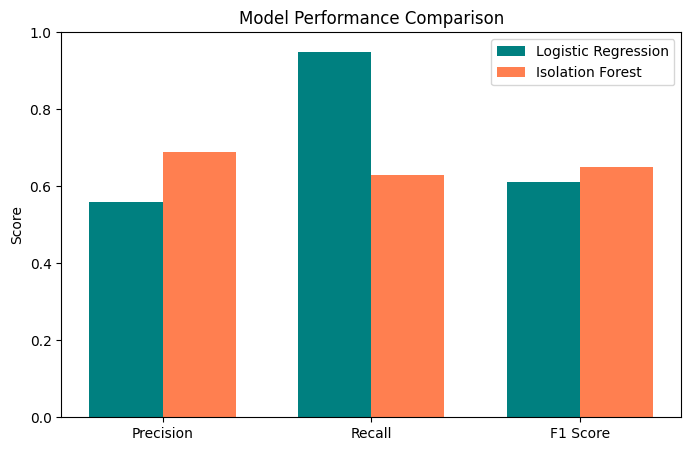

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Logistic Regression metrics
lr_precision = 0.56
lr_recall = 0.95
lr_f1 = 0.61

# Isolation Forest metrics
iso_precision = 0.69
iso_recall = 0.63
iso_f1 = 0.65

labels = ['Precision', 'Recall', 'F1 Score']

lr_values = [lr_precision, lr_recall, lr_f1]
iso_values = [iso_precision, iso_recall, iso_f1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, lr_values, width, label='Logistic Regression', color='teal')
plt.bar(x + width/2, iso_values, width, label='Isolation Forest', color='coral')

plt.xticks(x, labels)
plt.ylim(0,1)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

In [15]:
# Example transaction (from test set)
sample = X_test.iloc[0].values.reshape(1, -1)

# 1️⃣ Predicted class
pred_class = lr.predict(sample)[0]

# 2️⃣ Predicted probability of being fraud
pred_prob = lr.predict_proba(sample)[0][1]  # probability of class 1 (fraud)

# 3️⃣ Print result
if pred_class == 1:
    print(f"Transaction is FRAUD! Probability: {pred_prob:.4f}")
else:
    print(f"Transaction is NORMAL. Probability of fraud: {pred_prob:.4f}")

Transaction is NORMAL. Probability of fraud: 0.0012


In [19]:
y_prob = lr.predict_proba(X_test)[:,1]  # probability of fraud
y_pred = lr.predict(X_test)

for i in range(1076):  # first 10 transactions
    print(f"Transaction {i+1}: {'Fraud' if y_pred[i]==1 else 'Normal'} (Prob={y_prob[i]:.4f})")

Transaction 1: Normal (Prob=0.0012)
Transaction 2: Normal (Prob=0.0260)
Transaction 3: Normal (Prob=0.0000)
Transaction 4: Normal (Prob=0.0042)
Transaction 5: Fraud (Prob=0.9028)
Transaction 6: Normal (Prob=0.0025)
Transaction 7: Normal (Prob=0.0001)
Transaction 8: Normal (Prob=0.0086)
Transaction 9: Normal (Prob=0.0139)
Transaction 10: Normal (Prob=0.0035)
Transaction 11: Normal (Prob=0.0783)
Transaction 12: Normal (Prob=0.1220)
Transaction 13: Normal (Prob=0.0006)
Transaction 14: Normal (Prob=0.0015)
Transaction 15: Normal (Prob=0.0075)
Transaction 16: Normal (Prob=0.0095)
Transaction 17: Normal (Prob=0.0028)
Transaction 18: Normal (Prob=0.0094)
Transaction 19: Normal (Prob=0.0033)
Transaction 20: Normal (Prob=0.3939)
Transaction 21: Normal (Prob=0.0330)
Transaction 22: Normal (Prob=0.0194)
Transaction 23: Normal (Prob=0.0165)
Transaction 24: Normal (Prob=0.0057)
Transaction 25: Normal (Prob=0.0057)
Transaction 26: Normal (Prob=0.0270)
Transaction 27: Normal (Prob=0.0000)
Transaction

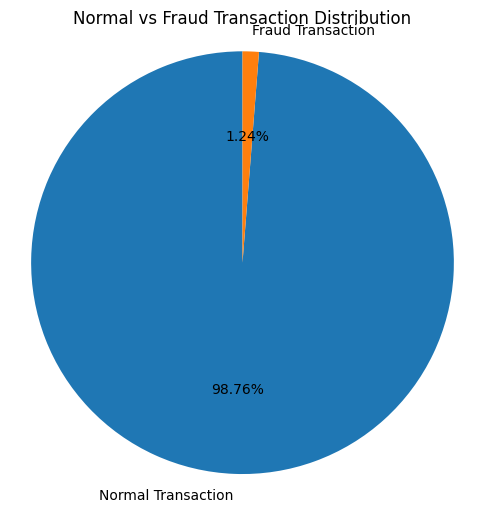

In [24]:
# Predict transactions
y_prob = lr.predict_proba(X_test)[:,1]
y_pred = lr.predict(X_test)

# Count Normal and Fraud
normal_count = np.sum(y_pred == 0)
fraud_count = np.sum(y_pred == 1)

labels = ['Normal Transaction', 'Fraud Transaction']
sizes = [normal_count, fraud_count]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)

plt.title("Normal vs Fraud Transaction Distribution")
plt.axis('equal')   

plt.show()

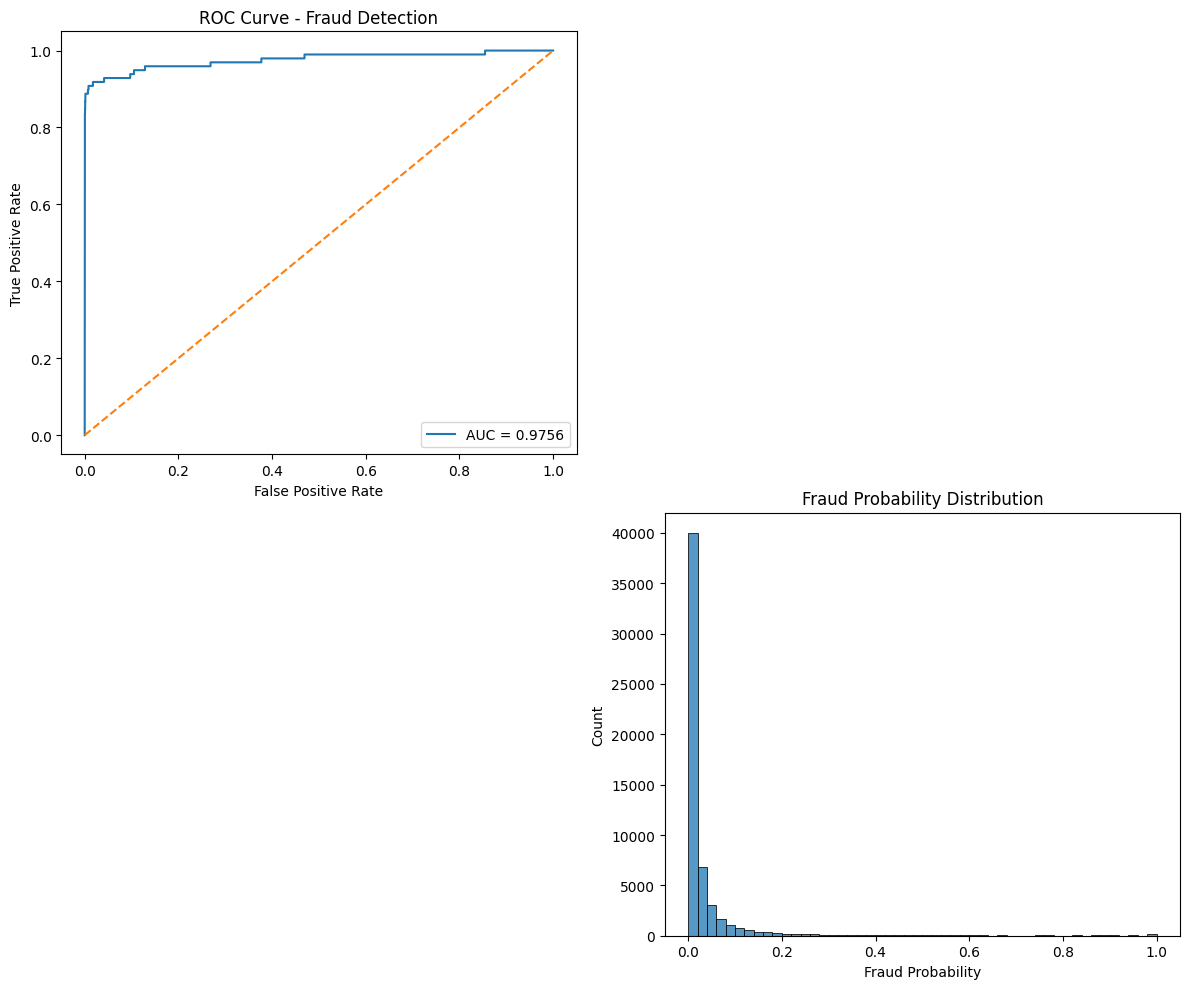

In [26]:
# Predictions
y_prob = lr.predict_proba(X_test)[:,1]
y_pred = lr.predict(X_test)

# Create dashboard layout
plt.figure(figsize=(12,10))

# =============================
# ROC Curve
# =============================
plt.subplot(2,2,1)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
# =============================
# Fraud Probability Distribution
# =============================
plt.subplot(2,2,4)

sns.histplot(y_prob, bins=50)

plt.title("Fraud Probability Distribution")
plt.xlabel("Fraud Probability")
plt.ylabel("Count")

plt.tight_layout()
plt.show()